# Immunoglobulin ML — Model Training

**Author:** Jesse Gunn Cheu 
**Date:** 2026-04-01  
**Description:** This project utilizes machine learning techniques in order to conduct an analysis on immunglobulin gene annotations. These annotations are output from the program DIGGER and were manuall;y curated by Ashley Reers at Tulane University.

**Acknowledgements:** This project served as a cummulating project for an applied machine learning course taught by Dr. Brian King. This work has been conducted during my time as a researcher in the Field Lab at bucknell University and our datasets come from our *Epomorphous labiatus* bat genome. Lastly, generative AI including ChatGPT, Claude AI, and vscode's copilot was used in constructing this notebook. The code has all been reviewed and editing by myself however and I have taken my time to review my usage of AI throughout my work here.

## Dependencies
 - Python 3.13.11

### Standard Library
- `__future__`
- `itertools`
- `time`

### Core
- `numpy`
- `pandas`

### Visualization
- `matplotlib`
- `seaborn`

### Scientific / Stats
- `scipy`
- `sklearn` (scikit-learn)

### Local Modules
- `kmer_polished`

In [191]:
# Import Packages
# Basics
from __future__ import annotations
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
import importlib

# Stats & Viz
from itertools import combinations # Suggested by ChatGPT
from scipy.stats import zscore
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import pairwise_distances
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay, f1_score, log_loss
from sklearn import tree
from sklearn.metrics import ConfusionMatrixDisplay

# Train/Test Split & CV
from sklearn.model_selection import train_test_split, KFold
from sklearn.utils import shuffle
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.model_selection import GridSearchCV

# Classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# MINE
import kmer_polished
importlib.reload(kmer_polished)

<module 'kmer_polished' from 'w:\\Projects\\ImmunoglobulinML\\kmer_polished.py'>

# Loading in data
As you may be able to notice, the data is not open source in this repository as our data has not yet been published for public use. It can be made upon request to jjgc001@bucknell.edu and/or kfield@bucknell.edu

What is important to know is that our data comes from two gff files. One is the direct output from digger which will be refered to as *raw* and the other is a manually curated gff file which will be refered to as *cur*. 

In [192]:
# Loading data or making dataframes from gff files if csv files not found
try :
    raw_df = pd.read_csv('igl_raw_2_ 3_ 6_kmers.csv')
except FileNotFoundError:
    print("File not found for raw_df, making raw_df from gff")
    raw_df = kmer_polished.beautify_gff("HLepoLabi.1.2.h1.cur.20251110.2bit", "Data/epolab_hap1_digger_igl_annotations_raw.gff", "raw")

try :
    cur_df = pd.read_csv('igl_cur_2_ 3_ 6_kmers.csv')
except FileNotFoundError:
    print("File not found for cur_df, making cur_df from gff")
    cur_df = kmer_polished.beautify_gff("HLepoLabi.1.2.h1.cur.20251110.2bit", "Data/epolab_hap1_digger_annotations_igl_polished.gff", "cur")

# Create a merged dataframe and extract gene_type and gene_function from the 'feature' column using regex
full_df = pd.concat([raw_df, cur_df], ignore_index=True)
full_df[['gene_type', 'gene_function']] = full_df['feature'].str.extract(r'(\S+)\s+\(([^)]+)\)')

C:\Users\jesse\AppData\Local\Temp\ipykernel_41324\3436385979.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_df[['gene_type', 'gene_function']] = full_df['feature'].str.extract(r'(\S+)\s+\(([^)]+)\)')


# Exploratory Data Analysis
Before begining the machine learning process, I wanted to take a brief look to see what gene types might hold the most information / be the most useful to conduct this process on. I am specifically looking for gene types that have a larger number in the raw file than the curated file. This would signal to us that there were genes filtered out during the manual curation process that we could then use for our analysis.

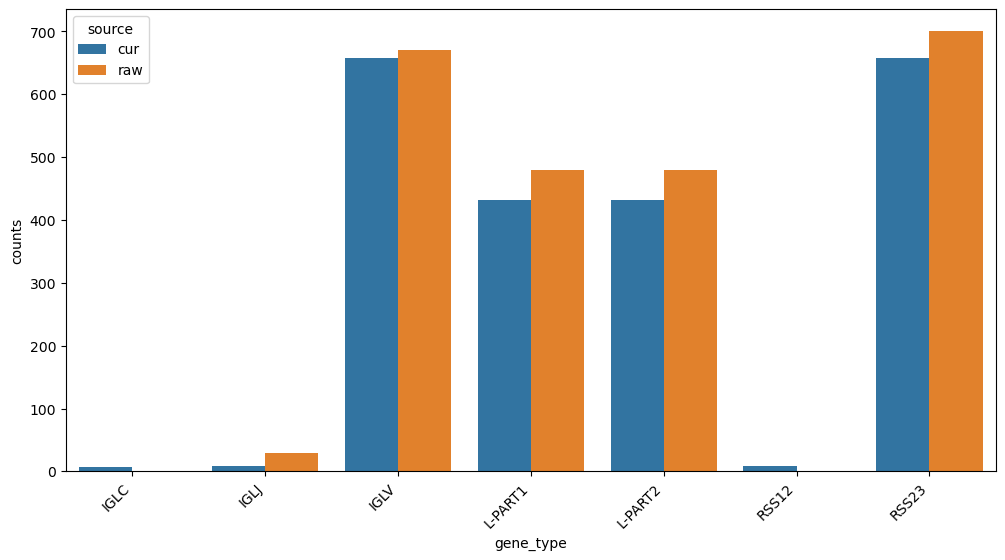

In [193]:
# Take a look at the distribution of features in the raw and polished datasets
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=full_df.groupby(['source', 'gene_type']).size().reset_index(name='counts'),
    x='gene_type',
    y='counts',
    hue='source'
)
# Rotate x-axis labels for better readability and move to the right
plt.xticks(rotation=45, ha='right')

#save graph
plt.savefig(f"viz/feature_counts.png", bbox_inches='tight')

Like I said before, we want to look at genes with the greatest difference between the curated and raw files but importantly with the raw file having more genes than the curated file.

In [194]:
# Get differences in feature counts between raw and polished datasets
feature_counts = full_df.groupby(['source', 'gene_type']).size().reset_index(name='counts').pivot(index='gene_type', columns='source', values='counts').fillna(0)
feature_counts['difference'] = feature_counts['cur'] - feature_counts['raw']
feature_counts = feature_counts.sort_values(by='difference', ascending=True)
print(feature_counts[['raw', 'cur', 'difference']])

source       raw    cur  difference
gene_type                          
L-PART1    479.0  432.0       -47.0
L-PART2    479.0  432.0       -47.0
RSS23      700.0  658.0       -42.0
IGLJ        29.0    9.0       -20.0
IGLV       671.0  658.0       -13.0
IGLC         0.0    7.0         7.0
RSS12        0.0    9.0         9.0


HERE I WILL EXPLAIN WHY I CHOSE IGLJ

# Preprocessing

Although we did some data cleaning in the first step with reading in the files, we are now going to choose a specific gene type to analyze and further reduce our dataset using this feature.

In [283]:
# This is the gene type the analysis will be conducted on
selected_feature = "IGLV"

In [284]:
%%time
filter_full = full_df[full_df['gene_type'] == selected_feature].copy()

# Find kmer columns
mer_cols = [col for col in filter_full.columns if "mer" in col]

# Drop single-value kmer columns in one operation
cols_to_drop = [col for col in mer_cols if filter_full[col].nunique() == 1]
filter_full.drop(columns=cols_to_drop, inplace=True)

# Downcast remaining kmer columns in one operation
mer_cols_remaining = [col for col in mer_cols if col not in cols_to_drop]
filter_full[mer_cols_remaining] = filter_full[mer_cols_remaining].apply(pd.to_numeric, downcast="float")

# Categorical and index
filter_full['source'] = filter_full['source'].astype('category')
filter_full["seq_ID"] = [f"seq_{i}" for i in range(len(filter_full))]
filter_full = filter_full.set_index('seq_ID')

CPU times: total: 3.2 s
Wall time: 3.62 s


<timed exec>:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


# Remove similar sequences

As I mentioned before, there are genes in the raw file that are going to be similar to genes in the curated file because they are the same or only slightly altered and kept. This step is to make sure that any kept genes are denoted in the curated file and not the raw file. This is to ensure our classifier will have two distinct classes of "correct" or "incorrect" gene annotations and anything that is kept will be considered correct.

In [285]:
# Reformat to only numeric columns for pdist
num_df = filter_full.select_dtypes(include=[np.number])
num_df = num_df.drop(columns=['length']) # Drop non-informative columns
num_df_rounded = num_df.round(10) # Round to 10 decimal places to reduce memory usage and prevent floating point precision issues

In [286]:
# Create distance matrix
pdist_matrix = pairwise_distances(num_df_rounded, metric='euclidean')
distmat = pd.DataFrame(pdist_matrix, index=num_df_rounded.index, columns=num_df_rounded.index) # Automatic help from CoPilot
print(distmat.shape)
distmat.head(3)

(1329, 1329)


seq_ID,seq_0,seq_1,seq_2,seq_3,seq_4,seq_5,seq_6,seq_7,seq_8,seq_9,...,seq_1319,seq_1320,seq_1321,seq_1322,seq_1323,seq_1324,seq_1325,seq_1326,seq_1327,seq_1328
seq_ID,,,,,,,,,,,,,,,,,,,,,
seq_0,0.000000e+00,7.143336e+06,7.178213e+06,7.192744e+06,7.218229e+06,7.233495e+06,1.010387e+07,1.011209e+07,1.011954e+07,1.012589e+07,...,1.016421e+07,1.015678e+07,1.014917e+07,1.014179e+07,1.013622e+07,1.012987e+07,1.012589e+07,1.011954e+07,1.011209e+07,1.010387e+07
seq_1,7.143336e+06,0.000000e+00,3.487663e+04,4.940767e+04,7.489321e+04,9.015894e+04,2.960534e+06,2.968751e+06,2.976208e+06,2.982552e+06,...,3.020875e+06,3.013449e+06,3.005838e+06,2.998451e+06,2.992880e+06,2.986533e+06,2.982552e+06,2.976208e+06,2.968751e+06,2.960534e+06
seq_2,7.178213e+06,3.487663e+04,0.000000e+00,1.453105e+04,4.001659e+04,5.528232e+04,2.925658e+06,2.933874e+06,2.941332e+06,2.947675e+06,...,2.985999e+06,2.978572e+06,2.970961e+06,2.963574e+06,2.958004e+06,2.951656e+06,2.947675e+06,2.941332e+06,2.933874e+06,2.925658e+06


In [287]:
# Reformat the output so we can see all the sequence pairs and distances
tmp = distmat.copy()
tmp.index.name = "row_id"
tmp.columns.name = "col_id"

pairs_df = (
    tmp.stack()
       .reset_index()
       .rename(columns={"row_id": "seq_first", "col_id": "seq_second", 0: "distance"})
)

pairs_df = pairs_df[pairs_df["seq_first"] < pairs_df["seq_second"]] # Keep only one of the two pairs (seq1, seq2) and (seq2, seq1) since they are the same distance
print(pairs_df.shape)
pairs_df.head(3)

(882456, 3)


,seq_first,seq_second,distance
1,seq_0,seq_1,7.143336e+06
2,seq_0,seq_2,7.178213e+06
3,seq_0,seq_3,7.192744e+06


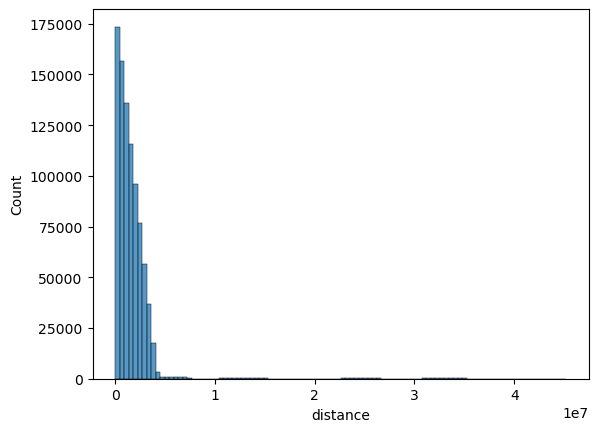

In [288]:
sns.histplot(pairs_df["distance"], bins=100)
plt.savefig(f"viz/distance_histogram_{selected_feature}.png", bbox_inches='tight')

I am looking at this plot in order to see if there is a cutoff point other than 0 that might show if two sequences are similar enough to call the same.

In [289]:
# Identify duplicates based on a distance threshold
pairs_dup = pairs_df[pairs_df["distance"] < 1e-10] # This threshold is based on the precision of the distance calculations and can be adjusted as needed
seq_ids = set(pairs_dup["seq_first"]).union(set(pairs_dup["seq_second"]))
seq_ids_list = list(seq_ids)
seq_ids_list[:5] # This is what we are going to use to remove duplicates

['seq_1095', 'seq_243', 'seq_266', 'seq_552', 'seq_675']

In [290]:
# Filter out duplicates from Digger sequences only
before_count = filter_full.shape[0]
filter_full_cur = filter_full[filter_full["source"] == "cur"]
before_count_cur = filter_full_cur.shape[0]
filter_full_raw = filter_full[filter_full["source"] == "raw"]
before_count_raw = filter_full_raw.shape[0]
filter_full_raw = filter_full_raw[~filter_full_raw.index.isin(seq_ids_list)]
filter_final = pd.concat([filter_full_cur, filter_full_raw])
after_count = filter_final.shape[0]
print(f"Before count: {before_count}, After count: {after_count}")
print(f"curated count before: {before_count_cur}, digger count before: {before_count_raw}")
print(f"curated count: {filter_full_cur.shape[0]}, digger count: {filter_full_raw.shape[0]}")

Before count: 1329, After count: 671
curated count before: 658, digger count before: 671
curated count: 658, digger count: 13


Now we can see that a total of 42 annotations were removed from the raw DIGGER output.

# Exploratory Data Analysis 2

For the second part of my EDA I am going to first check distribution to see if it is more even now that I have removed the duplicates. I am then goign to look at some PCA plots to see if there are any clear divisions between my two classes. I will also then see if any specific features are highly different between the classes in their counts which will serve as an indicator for kmers that might serve as important markers for distinguishing correct and incorrect annotations.

In [291]:
# Feel free to adjust the color palette as needed for better visualization
color_palette = ["#FF6347", "#4682B4"] # Tomato and Steel Blue

C:\Users\jesse\AppData\Local\Temp\ipykernel_41324\1055389407.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filter_viz, x='source', y='counts', palette=color_palette);


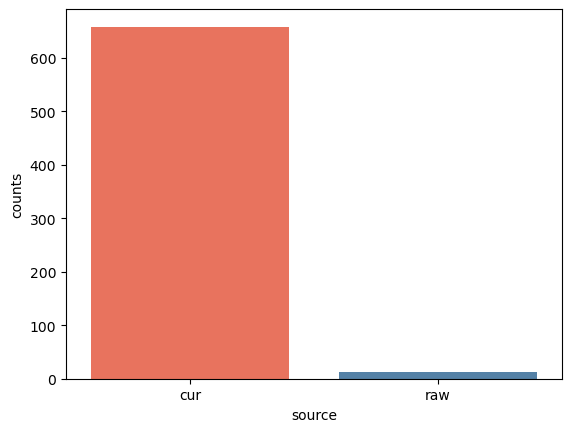

In [292]:
# Visualize final counts to see distribution between classes
filter_viz = filter_final.groupby('source').size().reset_index(name = 'counts');
sns.barplot(data=filter_viz, x='source', y='counts', palette=color_palette);
plt.savefig(f'viz/post_filter_counts_{selected_feature}.png', bbox_inches='tight')

We can see that we have a fairly unevenly distributed target variable here. This will be important to take into consideration with our classifiers.

In [293]:
# Perform PCA
pca_df = pd.concat([filter_final.loc[:, filter_final.columns.str.contains("mer")]], axis=1)
zscore_df = pca_df.apply(zscore)

pca = PCA(pca_df.shape[0])
pca_df = pd.DataFrame(pca.fit_transform(zscore_df))

# Generated by ChatGPT
summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(pca.n_components_)],
    "Explained Variance": pca.explained_variance_,
    "Explained Variance Ratio": pca.explained_variance_ratio_,
})

print(summary.head(5))

    PC  Explained Variance  Explained Variance Ratio
0  PC1          167.996490                  0.043222
1  PC2          149.949188                  0.038579
2  PC3          122.090927                  0.031412
3  PC4          116.659470                  0.030014
4  PC5          107.491920                  0.027656


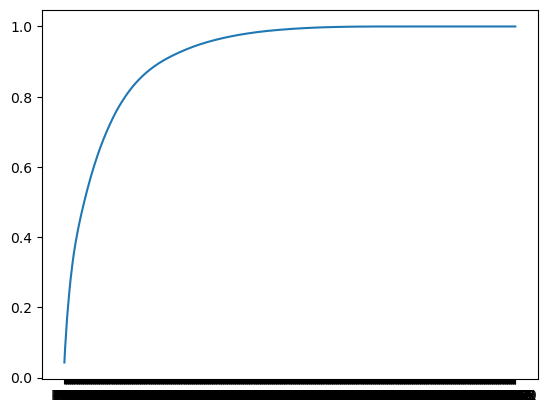

In [294]:
# Plot cumulative explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_) # Help from ChatGPT
plt.plot([f"PC{i}" for i in range(1, pca_df.shape[0] + 1)], cum_var)
plt.savefig(f"viz/cumulative_explained_variance_{selected_feature}.png", bbox_inches='tight')

It does not seem like we can reliably compress our data into a small number of dimensions.

In [295]:
# Create a new DataFrame for plotting with the first 3 principal components and the source column
pca_plot_df = pd.concat([pca_df.iloc[:, 0:3], filter_final['source'].reset_index(drop=True)], axis=1)
pca_plot_df.columns = ['PC1', 'PC2', 'PC3', 'source']

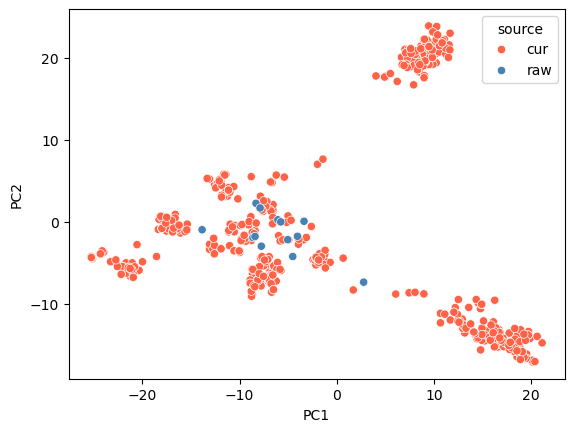

In [296]:
sns.scatterplot(data=pca_plot_df, x='PC1', y='PC2', hue='source', palette=color_palette)
plt.savefig(f"viz/pca_scatter_{selected_feature}.png", bbox_inches='tight')

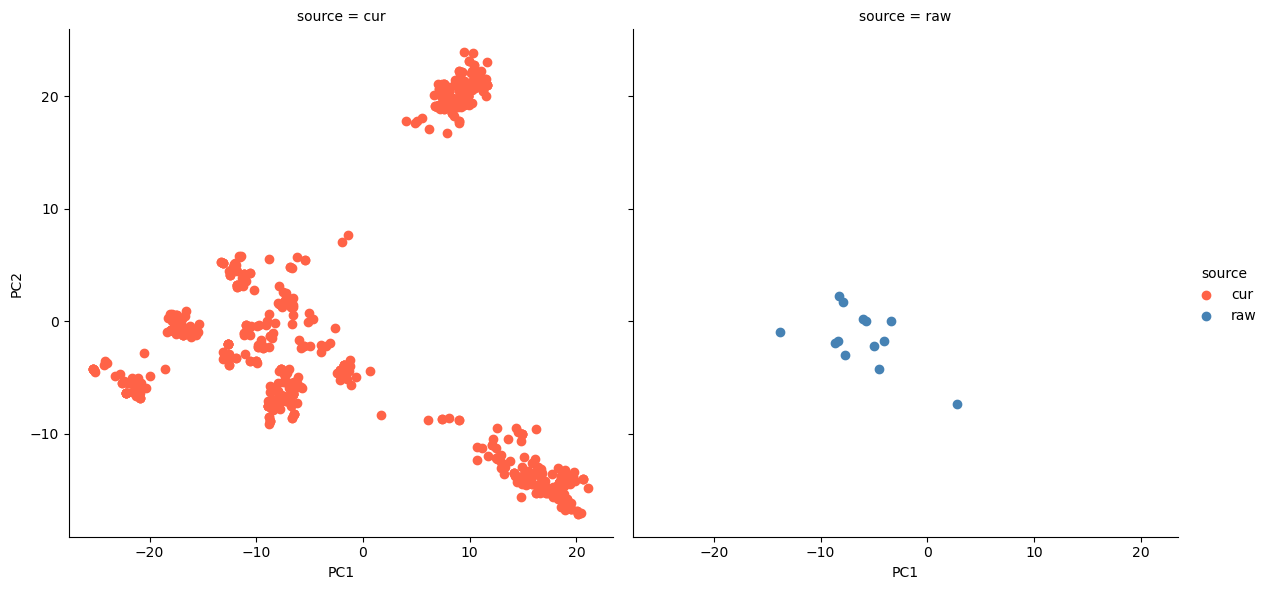

In [297]:
# This is to see if there was overlap that can be difficult to see if there was a lot of overlap
g = sns.FacetGrid(pca_plot_df, col = 'source', hue="source", height=6, palette=color_palette)
g.map(plt.scatter, "PC1", "PC2").add_legend()
plt.savefig(f"viz/pca_scatter_facet_{selected_feature}.png", bbox_inches='tight')

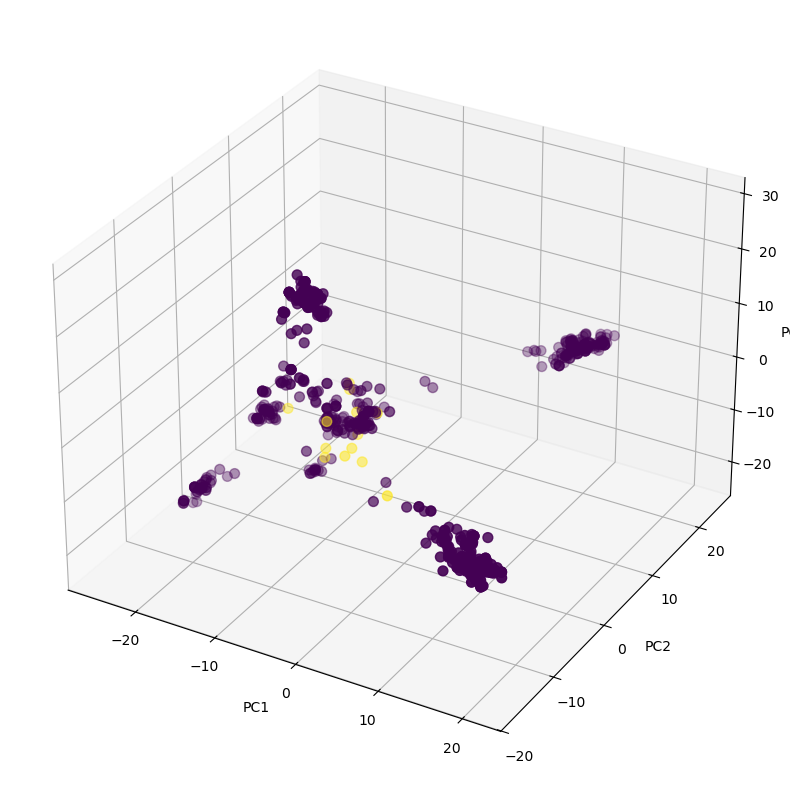

In [298]:
# Plot the first 3 principal components in a 3D scatter plot colored by source
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pca_plot_df.iloc[:,0], pca_plot_df.iloc[:,1], pca_plot_df.iloc[:,2], c=pca_plot_df['source'].cat.codes, cmap="viridis", s=50)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.savefig(f"viz/pca_scatter_3d_{selected_feature}.png", bbox_inches='tight')


In [299]:
# This is to see which kmers are most different between the raw and polished datasets
kmer_cols = filter_final.columns.str.contains("mer", regex=False)
source_col = filter_final.columns == "source"

split_df = (
    filter_final.loc[:, kmer_cols | source_col]
    .melt(id_vars="source", var_name="kmer")
    .groupby(["kmer", "source"])["value"]
    .mean()
    .unstack("source")
    .assign(difference=lambda x: x["cur"] - x["raw"])
    .assign(direction=lambda x: np.where(x["difference"] > 0, "Higher in Curated", "Higher in Raw"))
    .assign(abs_difference=lambda x: x["difference"].abs())
    .sort_values("abs_difference", ascending=False)
)

In [300]:
split_df.head(10)

source,cur,raw,difference,direction,abs_difference
kmer,,,,,
2mer_TT,0.031144,0.052925,-0.021781,Higher in Raw,0.021781
2mer_AT,0.041845,0.055841,-0.013996,Higher in Raw,0.013996
2mer_GG,0.081689,0.069741,0.011948,Higher in Curated,0.011948
2mer_CG,0.030135,0.020068,0.010067,Higher in Curated,0.010067
2mer_CC,0.095175,0.085225,0.009950,Higher in Curated,0.009950
3mer_TTC,0.011006,0.020316,-0.009310,Higher in Raw,0.009310
2mer_AA,0.033358,0.042220,-0.008862,Higher in Raw,0.008862
3mer_GTG,0.017600,0.009582,0.008018,Higher in Curated,0.008018
2mer_GC,0.067120,0.059583,0.007537,Higher in Curated,0.007537


C:\Users\jesse\AppData\Local\Temp\ipykernel_41324\3137316575.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha="right");


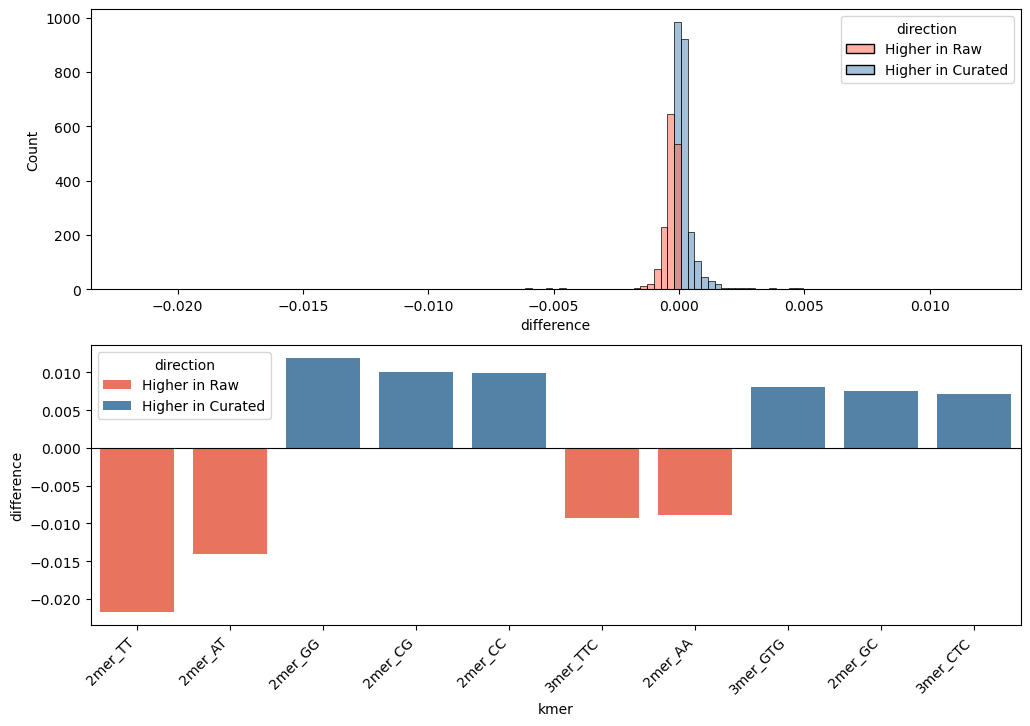

In [301]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8));

sns.histplot(split_df, x = "difference", hue = "direction", palette=color_palette, ax=ax[0]);

sns.barplot(split_df.head(10), x = "kmer", y="difference", hue = "direction", palette=color_palette, ax=ax[1]);
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha="right");
plt.savefig(f"viz/kmer_differences_{selected_feature}.png", bbox_inches='tight')

Firstly that there is not a huge difference between the two classes overall as we can see from the histogram being fairly close to 0. We can also see from the second graph which sequences seem to be the most different between the two classes which might be a clue as to which features might be important for determining if an annotations is correct or incorrect.

# Classifier
For now I am going to just make a simple decision tree then move into using logistic regression. A decision tree will be interesting for this data becuase it can show what features / kmers can be important for splitting the data. I will then use logistic regression because it will be better at handling the data because of the high number of features it has and I think it will create a stronger model using weights.

In [302]:
# Create X and Y for ML

X_2 = filter_final.loc[:, filter_final.columns.str.contains("2mer")] # Create a training set for 2mers
X_3 = filter_final.loc[:, filter_final.columns.str.contains("3mer")] # Create a training set for 3mers
X_6 = filter_final.loc[:, filter_final.columns.str.contains("6mer")] # Create a training set for 6mers
X_ALL = filter_final.loc[:, filter_final.columns.str.contains("mer")]

#X = pd.concat([X, filter_final['length']], axis=1) # I decided not to include length for now as I want to focus on if this problem can be solved using Kmers
Y = filter_final['source'].cat.codes

In [303]:
def decision_tree_analysis(X, Y, title):
    clf = DecisionTreeClassifier(random_state=0) # Basic Decision Tree Classifier

    pred_dt = cross_val_predict(clf, X, Y, cv=5) # Initial Test
    print(classification_report(Y, pred_dt)) # Show classification report

    fig, ax = plt.subplots(1, 2, figsize=(10,5))

    cfm = confusion_matrix(Y, pred_dt)
    ConfusionMatrixDisplay(confusion_matrix=cfm).plot(ax=ax[0])
    ax[0].set_title(title)

    clf.fit(X_2, Y)
    ax[1] = tree.plot_tree(
        clf,
        class_names=[str(c) for c in clf.classes_],
        feature_names=[str(f) for f in X.columns],
        filled=True
    );
    plt.savefig(f"viz/decision_tree_{title}_{selected_feature}.png", bbox_inches='tight')

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       658
           1       0.20      0.15      0.17        13

    accuracy                           0.97       671
   macro avg       0.59      0.57      0.58       671
weighted avg       0.97      0.97      0.97       671

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       658
           1       0.20      0.15      0.17        13

    accuracy                           0.97       671
   macro avg       0.59      0.57      0.58       671
weighted avg       0.97      0.97      0.97       671

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       658
           1       0.33      0.08      0.12        13

    accuracy                           0.98       671
   macro avg       0.66      0.54      0.56       671
weighted avg       0.97      0.98      0.97       671

              preci

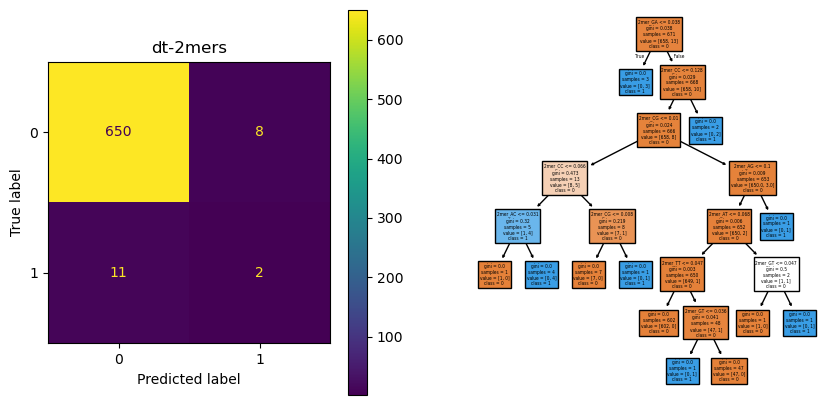

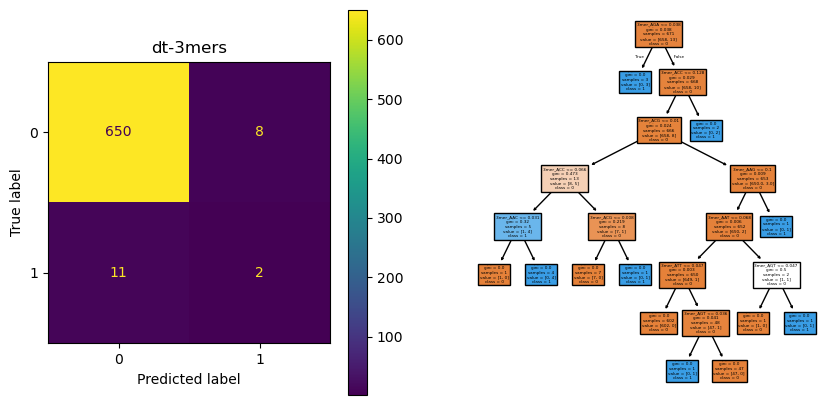

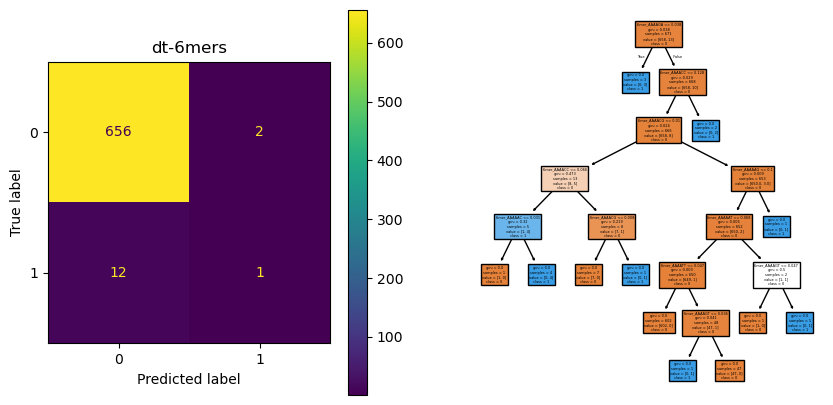

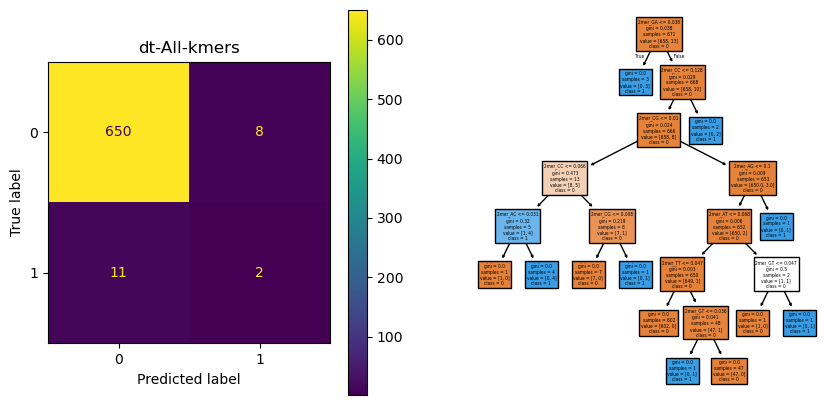

In [304]:
decision_tree_analysis(X_2, Y, "dt-2mers")
decision_tree_analysis(X_3, Y, "dt-3mers")
decision_tree_analysis(X_6, Y, "dt-6mers")
decision_tree_analysis(X_ALL, Y, "dt-All-kmers")

When I originally conducted this IGLH, I yielded very poor results where my classifier actually performed worse than simple random guessing. Again this is becuase of the huge overlap between the two classes. With IGLJ however we can see that there is a high degree of accuracy because the classes can actually be differentiated. An important part of this tool however is going to be to minimize the False negatives. We only want to remove the annotations that we are certain are inccorect with high confidence. Ideally we want to only check over the annotations we are confident are in the final dataset and minimize how many annotations we must manually look over. Because of this we want to maximize our precision metric.

In [305]:
def grid_search_decision_tree(X, name, Y):
    print(f"Running Grid Search for Decision Tree with {X.columns[0].split('mer')[0]}mers...")
    start_time = time.time()
    param_grid = { 'criterion' : ['gini', 'entropy'],
               'max_depth' : [4,5,6,7,8,9],
               'min_samples_split' : [3,4,5,6],
               'min_samples_leaf' : [1,2,3,4,5]
             }

    grid = GridSearchCV(DecisionTreeClassifier(), param_grid, scoring = ["precision"],
                    refit="precision", n_jobs=-1,
                    return_train_score=True, cv=10)

    grid_result = grid.fit(X,Y)
    end_time = time.time()
    print(f"Best score for decision tree with {name}: {grid_result.best_score_}")
    print(f"Best params for decision tree with {name}: {grid_result.best_params_}")
    print(f"Time taken for decision tree with {name}: {end_time - start_time:.2f} seconds")    

    return grid_result.best_score_, grid_result.best_params_

In [306]:
def iterate_decision_tree(X_list, names, Y):
    best_df = []
    best_score = 0
    best_params = []
    best_name = ""
    for X, name in zip(X_list, names):
        score, params = grid_search_decision_tree(X, name, Y)
        if score > best_score:
            best_df = X
            best_score = score
            best_params = params
            best_name = name
    try :
        if best_df == X_ALL:
            best_name = "All Kmers"
    except:
        pass
    print(f"Best overall score: {best_score} with {best_name} and params: {best_params['criterion']}, {best_params['max_depth']}, {best_params['min_samples_split']}, {best_params['min_samples_leaf']}")
    return best_df, best_score, best_params, best_name

In [307]:
dt_best_df, dt_best_score, dt_best_params, dt_best_name = iterate_decision_tree([X_2, X_3, X_6, X_ALL], ["2mer", "3mer", "6mer"], Y)

Running Grid Search for Decision Tree with 2mers...
Best score for decision tree with 2mer: 0.5
Best params for decision tree with 2mer: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 3}
Time taken for decision tree with 2mer: 6.28 seconds
Running Grid Search for Decision Tree with 3mers...
Best score for decision tree with 3mer: 0.6333333333333333
Best params for decision tree with 3mer: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 3, 'min_samples_split': 3}
Time taken for decision tree with 3mer: 9.07 seconds
Running Grid Search for Decision Tree with 6mers...
Best score for decision tree with 6mer: 0.35
Best params for decision tree with 6mer: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 3}
Time taken for decision tree with 6mer: 395.95 seconds
Best overall score: 0.6333333333333333 with 3mer and params: entropy, 9, 3, 3


              precision    recall  f1-score   support

           0       0.99      0.98      0.98       658
           1       0.27      0.31      0.29        13

    accuracy                           0.97       671
   macro avg       0.63      0.65      0.64       671
weighted avg       0.97      0.97      0.97       671



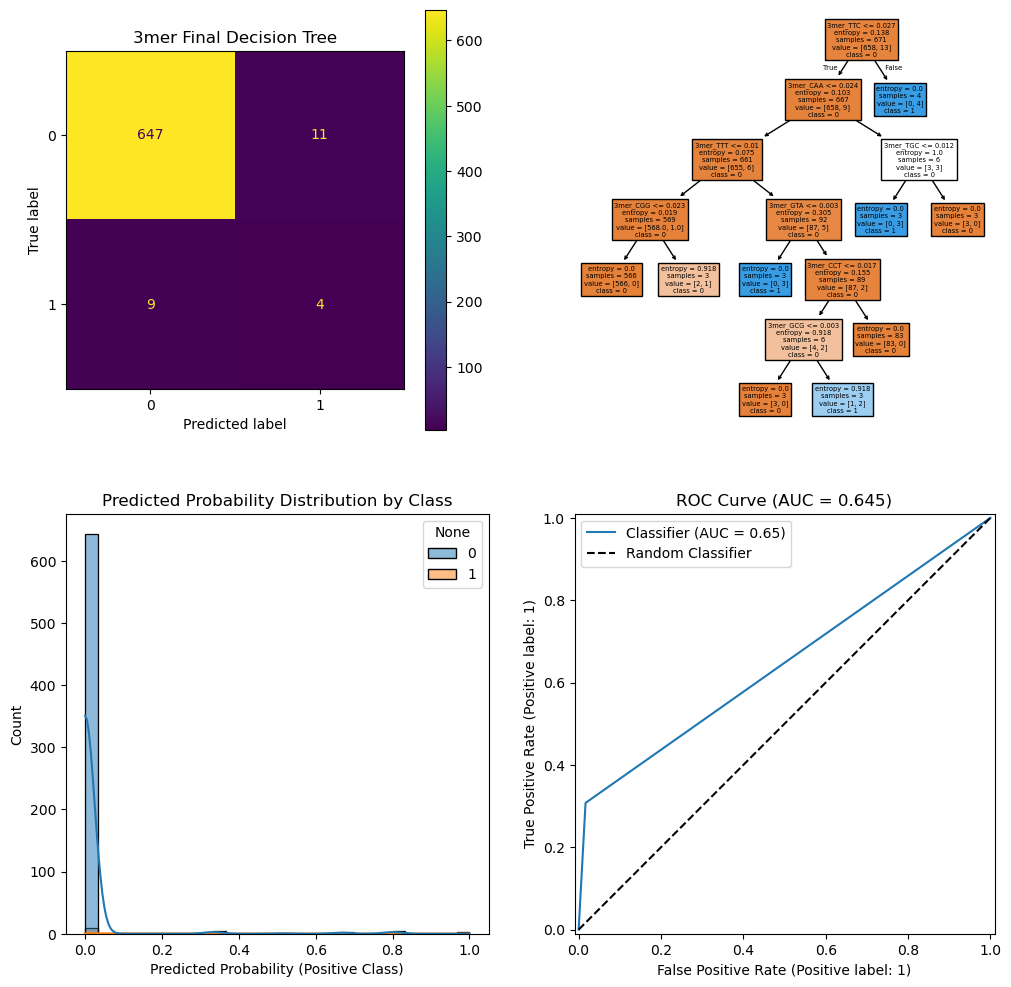

In [308]:
dt_final = DecisionTreeClassifier(criterion=dt_best_params['criterion'], max_depth=dt_best_params['max_depth'], min_samples_split=dt_best_params['min_samples_split'], min_samples_leaf=dt_best_params['min_samples_leaf']) # Decision Tree Classifier based on best params

pred_dt_final = cross_val_predict(dt_final, dt_best_df, Y, cv=5) # Initial Test
print(classification_report(Y, pred_dt_final)) # Show classification report
fig, ax = plt.subplots(2, 2, figsize=(12,12));

cfm = confusion_matrix(Y, pred_dt_final)
ConfusionMatrixDisplay(confusion_matrix=cfm).plot(ax=ax[0, 0])
ax[0, 0].set_title(f"{dt_best_name} Final Decision Tree")

dt_final.fit(dt_best_df, Y)
tree.plot_tree(
    dt_final,
    ax = ax[0, 1],
    class_names=[str(c) for c in dt_final.classes_],
    feature_names=[str(f) for f in dt_best_df.columns],
    filled=True
);

# REVIEW THIS, I DONT FULLY UNDERSTAND IT BUT I THINK IT IS RIGHT
pred_dt_proba = cross_val_predict(dt_final, dt_best_df, Y, cv=5, method='predict_proba')
sns.histplot(x=pred_dt_proba[:, 1], hue=Y, bins=30, ax=ax[1, 0], kde=True)
ax[1, 0].set_title("Predicted Probability Distribution by Class")
ax[1, 0].set_xlabel("Predicted Probability (Positive Class)")

# ROC Curve - CODE YOU CAN USE TO SHOW AN ROC CURVE!
roc_auc = roc_auc_score(Y, pred_dt_final)
RocCurveDisplay.from_predictions(Y, pred_dt_final, ax = ax[1, 1])
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.savefig(f"viz/final_decision_tree_{dt_best_name}_{selected_feature}.png", bbox_inches='tight')

Although we are looking for the best precision, it seems hard to reduce the 2-3 false negatives using a decision tree. Next we will perform the logistic regression to see how that performs compared to decision trees.

In [309]:
def logistic_regression_analysis(X, Y, title):
    clf_log = LogisticRegression(C=1, random_state=0, max_iter=1000, class_weight='balanced', solver = 'lbfgs')

    pred_log = cross_val_predict(clf_log, X, Y, cv=5) # Initial Test
    print(classification_report(Y, pred_log)) # Show classification report

    fig, ax = plt.subplots(1, 2, figsize=(10,5))

    cfm = confusion_matrix(Y, pred_log)
    ConfusionMatrixDisplay(confusion_matrix=cfm).plot(ax=ax[0])
    ax[0].set_title(title)

    # ROC Curve - CODE YOU CAN USE TO SHOW AN ROC CURVE!
    roc_auc = roc_auc_score(Y, pred_log)
    RocCurveDisplay.from_predictions(Y, pred_log, ax=ax[1])
    ax[1].set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.legend()
    plt.savefig(f"viz/logistic_regression_{title}_{selected_feature}.png", bbox_inches='tight')

              precision    recall  f1-score   support

           0       0.99      0.84      0.91       658
           1       0.07      0.62      0.12        13

    accuracy                           0.83       671
   macro avg       0.53      0.73      0.52       671
weighted avg       0.97      0.83      0.89       671

              precision    recall  f1-score   support

           0       0.99      0.85      0.91       658
           1       0.07      0.62      0.13        13

    accuracy                           0.84       671
   macro avg       0.53      0.73      0.52       671
weighted avg       0.97      0.84      0.90       671

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       658
           1       0.20      0.38      0.26        13

    accuracy                           0.96       671
   macro avg       0.59      0.68      0.62       671
weighted avg       0.97      0.96      0.96       671

              preci

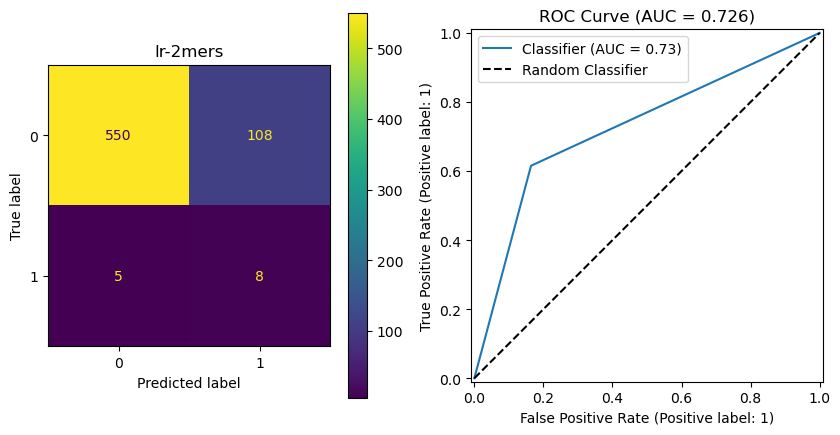

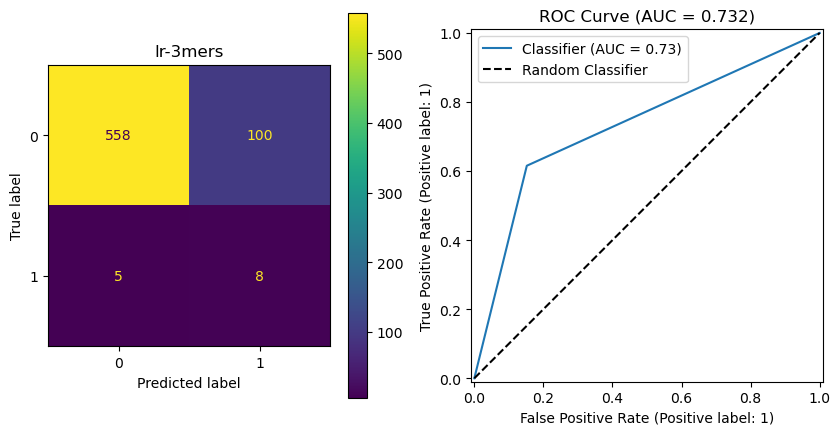

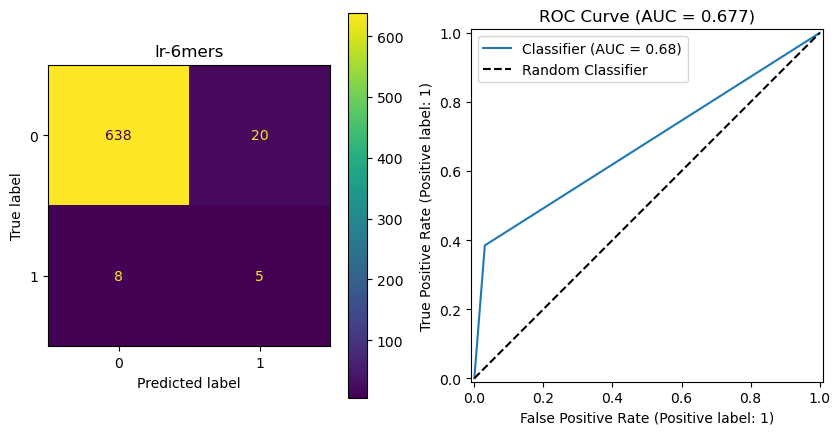

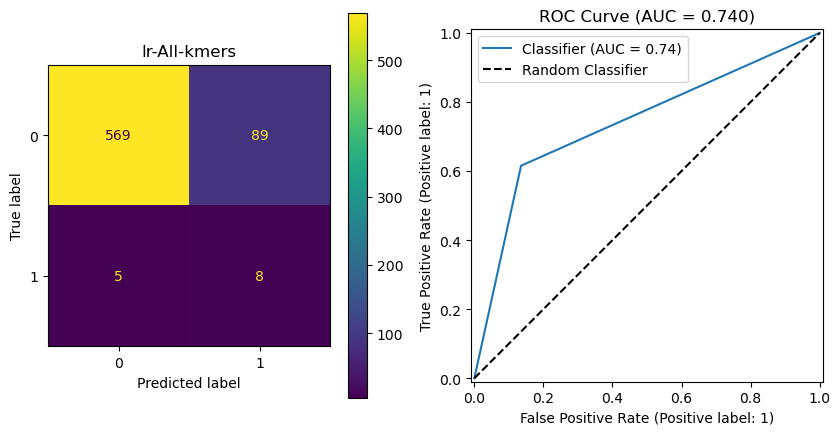

In [310]:
logistic_regression_analysis(X_2, Y, "lr-2mers")
logistic_regression_analysis(X_3, Y, "lr-3mers")
logistic_regression_analysis(X_6, Y, "lr-6mers")
logistic_regression_analysis(X_ALL, Y, "lr-All-kmers")

Off the bat it seems to better. Whats also interesting is that as we increased the size of the kmers, the AUC value increased. Lets use grid search again in order to see if we can maximize the precision metric. I will say while playing with this I on accident chose the trimer data and saw I got good results which is why I opted to use this data.

In [311]:
def grid_search_logistic_regression(X, name, Y):
    print(f"Running Grid Search for Logistic Regression with {X.columns[0].split('mer')[0]}mers...")
    start_time = time.time()
    param_grid = { 'C' : [0.1, 1, 10, 100, 1000],
            'class_weight' : ['balanced', None],
            'solver' : ['lbfgs', 'liblinear', 'sag', 'saga', 'newton-cg']
            }

    grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, scoring = ["precision"],
                        refit="precision", n_jobs=-1,
                        return_train_score=True, cv=10)

    grid_result = grid.fit(X,Y)
    end_time = time.time()
    print(f"Best score for logistic regression with {name}: {grid_result.best_score_}")
    print(f"Best params for logistic regression with {name}: {grid_result.best_params_}")
    print(f"Time taken for logistic regression with {name}: {end_time - start_time:.2f} seconds")    

    return grid_result.best_score_, grid_result.best_params_

In [312]:
def iterate_logistic_regression(X_list, names, Y):
    best_df = None
    best_score = 0
    best_params = []
    best_name = ""
    for X, name in zip(X_list, names):
        score, params = grid_search_logistic_regression(X, name, Y)
        if score > best_score:
            best_df = X
            best_score = score
            best_params = params
            best_name = name
    try :
        if best_df == X_ALL:
            best_name = "All Kmers"
    except:
        pass
    print(f"Best overall score: {best_score} with {best_name} and params: {best_params["C"]}, {best_params["class_weight"]}, {best_params["solver"]}")
    return best_df, best_score, best_params, best_name

In [ ]:
log_df, log_score, log_params, log_name = iterate_logistic_regression([X_2, X_3, X_6, X_ALL], ['2-mer', '3-mer', '6-mer'], Y)

Running Grid Search for Logistic Regression with 2mers...


c:\Users\jesse\anaconda3\envs\ImmunoglobulinML\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best score for logistic regression with 2-mer: 0.17956946039035593
Best params for logistic regression with 2-mer: {'C': 100, 'class_weight': 'balanced', 'solver': 'sag'}
Time taken for logistic regression with 2-mer: 3.87 seconds
Running Grid Search for Logistic Regression with 3mers...


c:\Users\jesse\anaconda3\envs\ImmunoglobulinML\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       0.95      1.00      0.98        20

    accuracy                           0.97        29
   macro avg       0.98      0.94      0.96        29
weighted avg       0.97      0.97      0.96        29



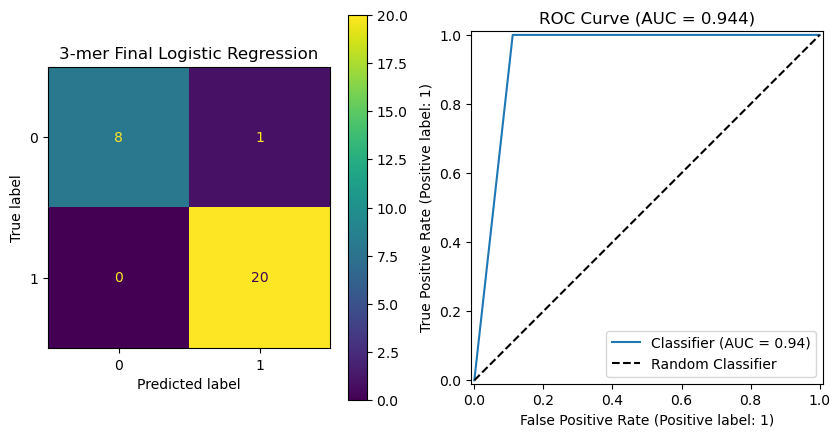

In [ ]:
clf_log_final = LogisticRegression(C = log_params['C'], max_iter = 1000, class_weight = log_params['class_weight'], solver = log_params['solver'])

pred_log_final = cross_val_predict(clf_log_final, log_df, Y, cv=10) # Initial Test
print(classification_report(Y, pred_log_final)) # Show classification report

fig, ax = plt.subplots(1, 2, figsize=(10,5))

cfm = confusion_matrix(Y, pred_log_final)
ConfusionMatrixDisplay(confusion_matrix=cfm).plot(ax=ax[0])
ax[0].set_title(f"3-mer Final Logistic Regression")

# ROC Curve - CODE YOU CAN USE TO SHOW AN ROC CURVE!
roc_auc = roc_auc_score(Y, pred_log_final)
RocCurveDisplay.from_predictions(Y, pred_log_final, ax=ax[1])
ax[1].set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.savefig(f"viz/final_logistic_regression_{log_name}_{selected_feature}.png", bbox_inches='tight')

We were able to get 100% precision using logistic regression! Lets take a look at the results that were incorrectly identified before finishing up.

In [ ]:
dt_false_results = pd.concat([pca_plot_df, pd.Series(pred_dt_final, name='Guess')], axis=1)
dt_false_results["Correct"] = np.where(dt_false_results['source'].cat.codes == dt_false_results['Guess'], 'Correct', 'Incorrect')
dt_false_results["Correct"] = dt_false_results["Correct"].astype('category')
dt_false_results.head(3)

,PC1,PC2,PC3,source,Guess,Correct
0,0.746613,-9.077331,-7.977273,cur,1,Incorrect
1,9.408231,0.413056,-3.083304,cur,0,Correct
2,9.503220,0.492595,-2.995938,cur,0,Correct


In [ ]:
log_false_results = pd.concat([pca_plot_df, pd.Series(pred_log_final, name='Guess')], axis=1)
log_false_results["Correct"] = np.where(log_false_results['source'].cat.codes == log_false_results['Guess'], 'Correct', 'Incorrect')
log_false_results["Correct"] = log_false_results["Correct"].astype('category')
log_false_results.head(3)

,PC1,PC2,PC3,source,Guess,Correct
0,0.746613,-9.077331,-7.977273,cur,1,Incorrect
1,9.408231,0.413056,-3.083304,cur,0,Correct
2,9.503220,0.492595,-2.995938,cur,0,Correct


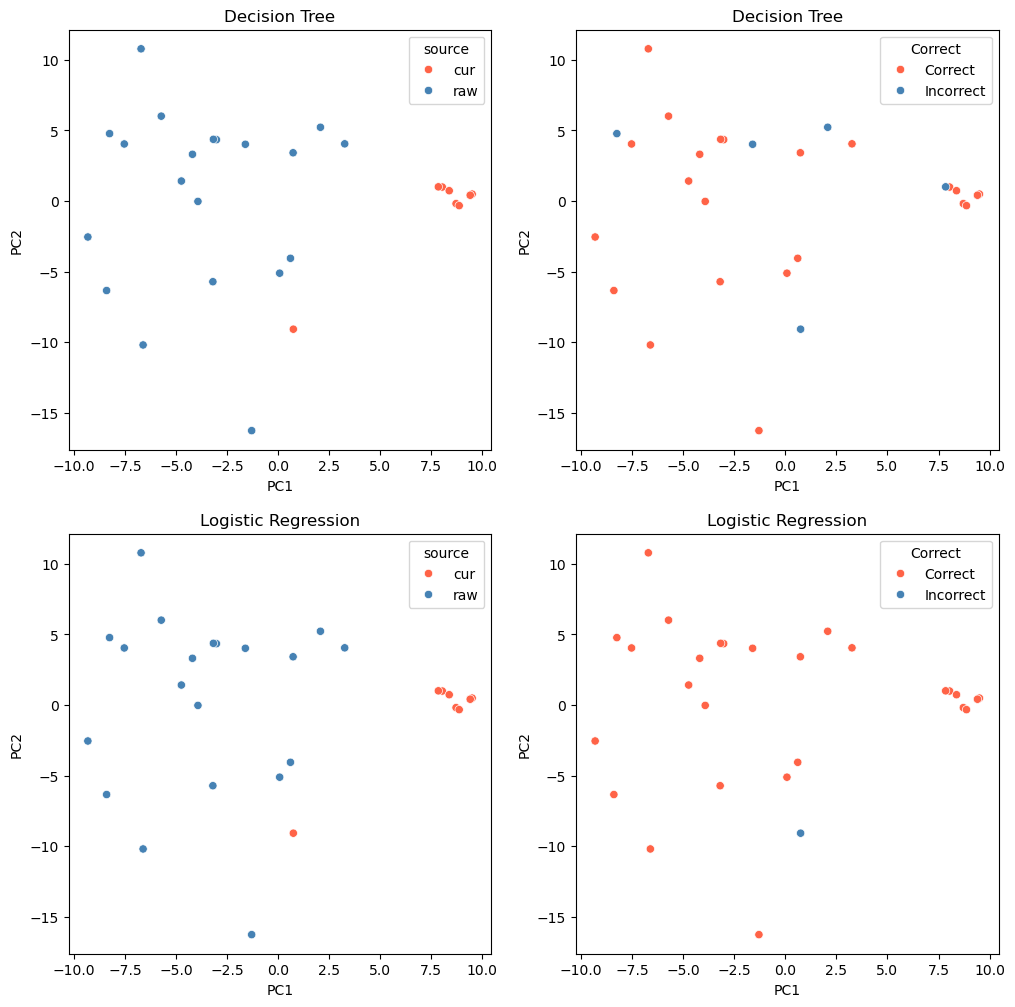

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 12));

sns.scatterplot(data=dt_false_results, x='PC1', y='PC2', hue='source', palette=color_palette, ax = ax[0, 0]);
ax[0, 0].set_title(f"Decision Tree")
sns.scatterplot(data=dt_false_results, x='PC1', y='PC2', hue='Correct', palette=color_palette, ax = ax[0, 1]);
ax[0, 1].set_title("Decision Tree")
sns.scatterplot(data=log_false_results, x='PC1', y='PC2', hue='source', palette=color_palette, ax = ax[1, 0]);
ax[1, 0].set_title("Logistic Regression")
sns.scatterplot(data=log_false_results, x='PC1', y='PC2', hue='Correct', palette=color_palette, ax = ax[1, 1]);
ax[1, 1].set_title("Logistic Regression")
plt.savefig(f"viz/false_results_{selected_feature}.png", bbox_inches='tight')

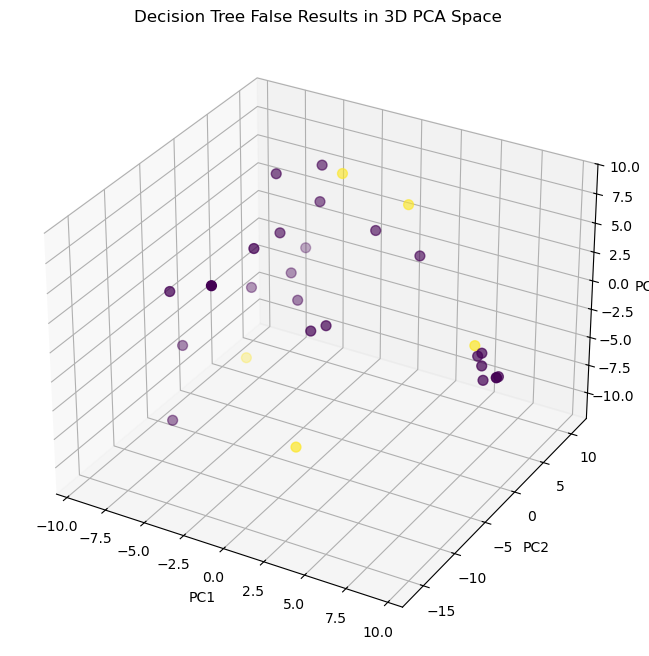

In [ ]:
fig = plt.figure(figsize = (8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(dt_false_results.iloc[:,0], dt_false_results.iloc[:,1], dt_false_results.iloc[:,2], c=dt_false_results['Correct'].cat.codes, cmap='viridis', s=50)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title(f"Decision Tree False Results in 3D PCA Space")
plt.savefig(f"viz/false_results_3d_{selected_feature}.png", bbox_inches='tight')

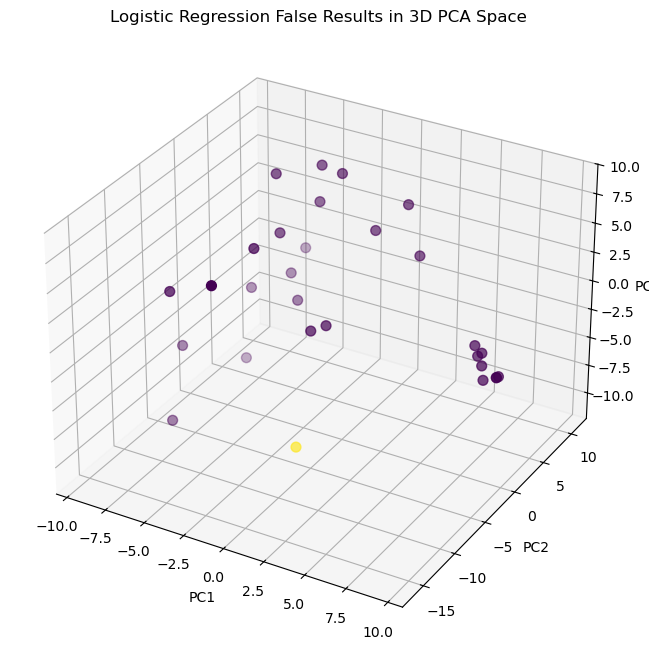

In [ ]:
fig = plt.figure(figsize = (8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(log_false_results.iloc[:,0], log_false_results.iloc[:,1], log_false_results.iloc[:,2], c=log_false_results['Correct'].cat.codes, cmap='viridis', s=50)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title(f"Logistic Regression False Results in 3D PCA Space")
plt.savefig(f"viz/logistic_false_results_3d_{selected_feature}.png", bbox_inches='tight')

I am unsure as to why the data points that were incorrectly identified were incorrectly identified because they are not on what I would imagine to be the border between the two classes.

# Conclusion

Ultimately this project was succesful in being able to differentiate raw digger output from polished curated annotations. We also were able to minimize the number of false negatives to 0 which would prevent the need for a user to review the annotations identified as incorrect. I think using a larger dataset would benefit this study in order to truly see how accurate it could be and to also see if it could have real world use.

# Acknowledgements

I would like to thank Dr Ken Field, Ashley Reers for guidance on the biological side of working on this project in addition to providing me with the data for this project. I would also like to thank Dr Brian King for his help on the technical side of this project.

ChatGPT and Copilot was used on this project for both coding and help understanding differences however everything written in a markdown is my own writing.